# Mandelbrot Set — Multi-Cell REPL

This notebook demonstrates the **incremental REPL** style of xeus-lfortran.
Variables declared in one cell persist in the global symbol table and are
available in every subsequent cell — just like a Python/Julia REPL.

`display_image` comes from the `lfortran_display` module that the kernel
injects automatically before the first user cell (same pattern as
xeus-swift's `kDisplaySetupCode` / `MimeBundleRepresentable` bootstrap).

## Step 1 — Parameters

In [1]:
integer, parameter :: Nx = 600, Ny = 450, n_max = 255, dp = kind(0.d0)
real(dp), parameter :: xcenter = -0.5_dp, ycenter = 0.0_dp, &
    width = 4.0_dp, height = 3.0_dp, &
    dx_di = width/Nx,  dy_dj = -height/Ny, &
    x_offset = xcenter - (Nx+1)*dx_di/2, &
    y_offset = ycenter - (Ny+1)*dy_dj/2

## Step 2 — Declare arrays

In [2]:
integer :: image(Nx, Ny), image_color(4, Nx, Ny), palette(3, 4)
integer :: i, j, n, idx
real(dp) :: x, y, x_0, y_0, x_sqr, y_sqr

## Step 3 — Compute escape iteration count

In [3]:
do j = 1, Ny
    y_0 = y_offset + dy_dj * j
    do i = 1, Nx
        x_0 = x_offset + dx_di * i
        x = 0; y = 0; n = 0
        do
            x_sqr = x ** 2; y_sqr = y ** 2
            if (x_sqr + y_sqr > 4 .or. n == n_max) then
                image(i,j) = 255 - n
                exit
            end if
            y = y_0 + 2 * x * y
            x = x_0 + x_sqr - y_sqr
            n = n + 1
        end do
    end do
end do
print *, "Computation done."

Computation done.


## Step 4 — Map to RGBA colour palette

In [4]:
palette(1,1) =   0; palette(2,1) = 135; palette(3,1) =  68
palette(1,2) =   0; palette(2,2) =  87; palette(3,2) = 231
palette(1,3) = 214; palette(2,3) =  45; palette(3,3) =  32
palette(1,4) = 255; palette(2,4) = 167; palette(3,4) =   0

do j = 1, Ny
    do i = 1, Nx
        idx = mod(image(i,j), 4) + 1
        image_color(1,i,j) = palette(1,idx)  ! R
        image_color(2,i,j) = palette(2,idx)  ! G
        image_color(3,i,j) = palette(3,idx)  ! B
        image_color(4,i,j) = 255             ! A
    end do
end do

## Step 5 — Display

`display_image` is the Fortran equivalent of `xcpp::display(img)` in xeus-cpp.
The kernel encodes the pixel array as a BMP and sends `{"image/bmp": base64}` to Jupyter.

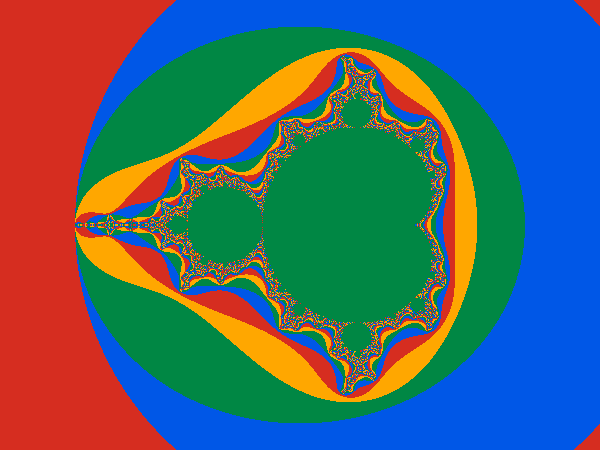

In [5]:
use lfortran_display, only: display_image
call display_image(Nx, Ny, image_color)

## Re-render with different palette

Because all variables persist, we can re-colour without re-computing.

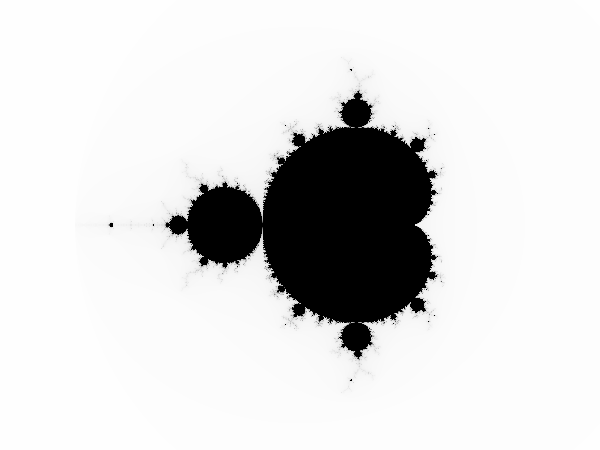

In [6]:
! Greyscale palette
do j = 1, Ny
    do i = 1, Nx
        n = image(i,j)
        image_color(1,i,j) = n  ! R
        image_color(2,i,j) = n  ! G
        image_color(3,i,j) = n  ! B
        image_color(4,i,j) = 255
    end do
end do
call display_image(Nx, Ny, image_color)